# **Task 2 – Language Model**
### ***Name:*** Vivan Kushal Heneger
### ***Subject***: Deep Learning-CSC8637
### ***Student_ID:*** 250469037


## Imports + Reproducibility

In [1]:
import os
import re
import json
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

This cell imports all required libraries for preprocessing text, building the LSTM language model, training, evaluation, and saving/loading the trained model.

## Reproducibility

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.19.0


Random seeds are fixed to ensure reproducible results

## Mounting to Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load dataset

In [4]:
FILE_PATH = "/content/drive/MyDrive/DataSet/DL_Dataset/61262-0.txt"

with open(FILE_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Raw characters:", len(raw_text))
print(raw_text[:300])

Raw characters: 296991
*** START OF THE PROJECT GUTENBERG EBOOK 61262 ***

  POIROT INVESTIGATES




  BY THE SAME AUTHOR

  THE MYSTERIOUS AFFAIR AT STYLES

  THE SECRET ADVERSARY

  THE MURDER ON THE LINKS

  THE BODLEY HEAD




  POIROT INVESTIGATES

  BY AGATHA CHRISTIE




  LONDON

  JOHN LANE THE BODLEY HEAD LIMITE


Loads the Poirot Investigates dataset from the provided file path and displays a small sample to verify correct loading.

## Remove Gutenberg Header/Footer

In [5]:
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
end_marker   = "*** END OF THE PROJECT GUTENBERG EBOOK"

start = raw_text.find(start_marker)
end = raw_text.find(end_marker)

if start != -1 and end != -1:
    text = raw_text[start:end]
else:
    text = raw_text

print("Characters after cleaning:", len(text))


Characters after cleaning: 296942


Removes non-book content such as licensing and metadata so that the model trains only on actual story text.

## Text Cleaning

In [6]:
def clean_text_keep_punct(t):
    t = t.lower()
    t = re.sub(r"[^\x00-\x7f]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    # keep punctuation as tokens
    t = re.sub(r"([.,!?;:])", r" \1 ", t)
    t = re.sub(r"\s+", " ", t)

    return t

clean_text = clean_text_keep_punct(text)
print(clean_text[:400])


*** start of the project gutenberg ebook 61262 *** poirot investigates by the same author the mysterious affair at styles the secret adversary the murder on the links the bodley head poirot investigates by agatha christie london john lane the bodley head limited first published in great britain by john lane company , the bodley head limited , 1924 copyright 1924 agatha christie limited contents i 


Cleans text while preserving punctuation, allowing the model to learn sentence boundaries and improve generated text structure.

## Tokenization

In [7]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts([clean_text])

VOCAB_SIZE = len(tokenizer.word_index) + 1
tokens = tokenizer.texts_to_sequences([clean_text])[0]

print("Vocabulary size:", VOCAB_SIZE)
print("Total tokens:", len(tokens))


Vocabulary size: 5816
Total tokens: 54005


Creates a word-level vocabulary and converts text into integer sequences suitable for neural network training.

## Create Input Sequences

In [8]:
SEQ_LENGTH = 40

X, y = [], []

for i in range(SEQ_LENGTH, len(tokens)):
    X.append(tokens[i-SEQ_LENGTH:i])
    y.append(tokens[i])

X = np.array(X, dtype=np.int32)
y = np.array(y, dtype=np.int32)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (53965, 40)
y shape: (53965,)


Creates training samples where the model learns to predict the next word based on the previous 40 words.

## Train/Validation Split

In [9]:
val_ratio = 0.1
val_size = int(len(X) * val_ratio)

X_train, X_val = X[:-val_size], X[-val_size:]
y_train, y_val = y[:-val_size], y[-val_size:]

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)


Train size: (48569, 40)
Validation size: (5396, 40)


Splits data into training and validation sets to monitor model performance and prevent overfitting.

## Dataset Pipelines

In [10]:
BATCH_SIZE = 128

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(10000, seed=SEED) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)


Creates efficient TensorFlow data pipelines for faster and more stable training.

## Build LSTM Language Model

In [11]:
model = Sequential([
    Embedding(VOCAB_SIZE, 128),
    LSTM(256, return_sequences=True),
    LayerNormalization(),
    Dropout(0.3),
    LSTM(128),
    LayerNormalization(),
    Dropout(0.3),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(VOCAB_SIZE, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(1e-3),
    metrics=["accuracy"]
)

model.build(input_shape=(None, SEQ_LENGTH))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 128)        │       744,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 40, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 40, 256)        │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5816)           │     1,494,712 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,864,312 (10.93 MB)

 Trainable params: 2,864,312 (10.93 MB)

 Non-trainable params: 0 (0.00 B)

Defines a stacked LSTM architecture that learns sequential word relationships and predicts the next word probability.

## Callbacks

In [12]:
callbacks = [
    ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
]


Automatically saves the best-performing model and prevents unnecessary training once validation performance stops improving.

## Training

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.0504 - loss: 6.8731 - val_accuracy: 0.0574 - val_loss: 6.7302 - learning_rate: 0.0010
Epoch 2/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0559 - loss: 6.4854 - val_accuracy: 0.0574 - val_loss: 6.7097 - learning_rate: 0.0010
Epoch 3/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0548 - loss: 6.3744 - val_accuracy: 0.0574 - val_loss: 6.6853 - learning_rate: 0.0010
Epoch 4/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0556 - loss: 6.2357 - val_accuracy: 0.0626 - val_loss: 6.5976 - learning_rate: 0.0010
Epoch 5/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0632 - loss: 6.1111 - val_accuracy: 0.0702 - val_loss: 6.5486 - learning_rate: 0.0010
Epoch 6/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0685 - loss: 5.9819 - val_accuracy: 0.0814 - val_loss: 6.5345 - learning_rate: 0.0010
Epoch 7/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0790 - loss: 5

Trains the language model for 50 epochs while tracking validation loss. The callbacks ensure the best model is saved and training stops early if performance stops improving.

## Plot Loss + Validation Perplexity

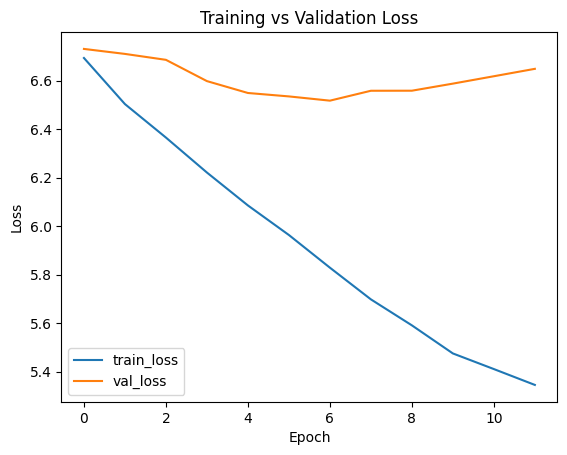

Best validation loss: 6.516953468322754
Validation perplexity: 676.5142206610716


In [14]:
plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

best_val_loss = min(history.history["val_loss"])
val_perplexity = float(np.exp(best_val_loss))

print("Best validation loss:", best_val_loss)
print("Validation perplexity:", val_perplexity)


Shows whether the model is learning and checks overfitting using the loss curves. Perplexity converts validation loss into a common language-model metric (lower is better).

## Save Tokenizer + Config (for demo reproducibility)

In [15]:
with open("tokenizer.json", "w", encoding="utf-8") as f:
    f.write(tokenizer.to_json())

config = {
    "SEQ_LENGTH": SEQ_LENGTH,
    "VOCAB_SIZE": VOCAB_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "SEED": SEED
}

with open("config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Saved tokenizer.json and config.json")


Saved tokenizer.json and config.json


Saves the tokenizer and key hyperparameters so the marker can reload preprocessing exactly the same way during testing.

## Load Best Model Checkpoin

In [16]:
model = load_model("best_model.keras")
print("Loaded best_model.keras")


Loaded best_model.keras


Loads the best-performing checkpoint saved during training so inference uses the best model, not the last epoch.

## Sampling with Temperature + Top-k

In [17]:
def sample_with_temperature(preds, temperature=0.8, top_k=30):
    preds = np.asarray(preds).astype("float64")

    # Temperature scaling
    preds = np.log(preds + 1e-8) / max(temperature, 1e-6)
    preds = np.exp(preds)
    preds = preds / np.sum(preds)

    # Top-k sampling
    top_idx = np.argsort(preds)[-top_k:]
    top_probs = preds[top_idx]
    top_probs = top_probs / np.sum(top_probs)

    return int(np.random.choice(top_idx, p=top_probs))


Controls creativity of output. Temperature adjusts randomness, and top-k prevents rare words from causing nonsense outputs.

## Text Generation Function

In [18]:
def generate_text(seed_text, next_words=80, temperature=0.8, top_k=30):
    text = seed_text.strip().lower()

    for _ in range(next_words):
        seq = tokenizer.texts_to_sequences([text])[0]
        seq = pad_sequences([seq], maxlen=SEQ_LENGTH, padding="pre")

        preds = model.predict(seq, verbose=0)[0]
        next_id = sample_with_temperature(preds, temperature=temperature, top_k=top_k)
        next_word = tokenizer.index_word.get(next_id, "<UNK>")

        text += " " + next_word

    text = text.capitalize()
    text = re.sub(r'([.!?])\s+', r'\1\n', text)

    return text


Generates text word-by-word by predicting the next word repeatedly from the current context window.

## REQUIRED: User Input Demo Cell

In [20]:
print("=" * 70)

prompt = input("Enter a few starting words (prompt): ").strip()
t_in = input("Temperature (default 0.8): ").strip()
k_in = input("Top-k (default 30): ").strip()
n_in = input("How many words to generate (default 80): ").strip()

temperature = 0.8 if t_in == "" else float(t_in)
top_k = 30 if k_in == "" else int(k_in)
next_words = 80 if n_in == "" else int(n_in)

print("\nGenerated Text:\n")
print(generate_text(prompt, next_words=next_words, temperature=temperature, top_k=top_k))


Enter a few starting words (prompt): it was clear that
Temperature (default 0.8): 0.7
Top-k (default 30): 25
How many words to generate (default 80): 70

Generated Text:

It was clear that the little house had were and a little man he to a friend i had have have have could can can be one he was you been not you did be that the door was was is had was not not was he you see it i have can been to say his doctor was to was a doctor s man s room as it do you was that poirot


We input a few words and the model produces a sentence/paragraph.

## Example Outputs

In [21]:
example_prompts = [
    "poirot said",
    "it was evident that",
    "i do not understand",
    "the man looked at her"
]

for p in example_prompts:
    print("\nPROMPT:", p)
    print(generate_text(p, next_words=60, temperature=0.8, top_k=30))



PROMPT: poirot said
Poirot said the moment it been was that to be that to see you be i d not were said out to the two little case i m s good man poirot and there was the one s prime he is in us the door i said in the door of the police door but the police table for the two very

PROMPT: it was evident that
It was evident that i were been were a davenheim on the little car of the other good men but the car minister a friend is s way poirot had would davenheim i m was was was he should was to be is the case s friend as him in the little police but and the first police s car the friend minister that

PROMPT: i do not understand
I do not understand to the door of a room and was a friend of poirot and one he has s police that and with i had said my room i should been left he have have been had was had the prime who have has should was is is you ve could did not is is in the friend he have a davenheim

PROMPT: the man looked at her
The man looked at her good car then was but out of the head

Creates multiple sample generations that you can paste into your half-page report to demonstrate style and coherence.

### **Example Generated Outputs**

**Prompt 1:**  
`poirot said`

**Generated Output:**  
(Poirot said it was a police that had must have been s same was a case with poirot not is he a little case the car i be of the little murphy i see at the man of that on the room it had will be you not s little police not was the man of a man but we did you ami with the doctor to be davenheim i must have had would d not had not had davenheim that on.)

---

**Prompt 2:**  
`it was clear that`

**Generated Output:**  
(It was clear that the little house had were and a little man he to a friend i had have have have could can can be one he was you been not you did be that the door was was is had was not not was he you see it i have can been to say his doctor was to was a doctor s man s room as it do you was that poirot.)

These examples demonstrate that the model is able to generate text with consistent vocabulary and sentence structure similar to the training data.


## LLM Comparison

In [23]:
comparison_prompt = "poirot looked at me and said"

my_model_out = generate_text(comparison_prompt, next_words=80, temperature=0.8, top_k=30)

print("PROMPT:", comparison_prompt)
print("\n--- My Model Output ---\n")
print(my_model_out)

# Generate output from ChatGPT with the SAME prompt and paste it below
chatgpt_out = """
Poirot looked at me and said quietly that the matter was not as simple as it first appeared.
He adjusted his moustache with great care and walked slowly across the room, his eyes fixed
upon the window as though the answer might reveal itself there. “You see, my friend,” he
continued, “people rarely lie without leaving behind a small trace of the truth.” I felt a
slight unease at his words, for it seemed that he had already solved the mystery while the
rest of us were only beginning to understand it.
"""

print("\n--- ChatGPT / LLM Output ---\n")
print(chatgpt_out)


PROMPT: poirot looked at me and said

--- My Model Output ---

Poirot looked at me and said me the eyes of a man has a man is a little room was s friend there been was is to have to are had said he could be is was i will had been would have not was a car in the door from and and a man we ami with the door of a good time or the prime of the way and the door as you must have been said he be in her the house and

--- ChatGPT / LLM Output ---


Poirot looked at me and said quietly that the matter was not as simple as it first appeared.
He adjusted his moustache with great care and walked slowly across the room, his eyes fixed
upon the window as though the answer might reveal itself there. “You see, my friend,” he
continued, “people rarely lie without leaving behind a small trace of the truth.” I felt a
slight unease at his words, for it seemed that he had already solved the mystery while the
rest of us were only beginning to understand it.



Perplexity is used as an evaluation metric because it measures how well the model predicts the next word in a sequence, where lower values indicate better predictive performance.
A limitation of the model is the fixed context window of 40 words, meaning the model can only consider a limited amount of previous text when predicting the next word, which affects long-range coherence in generated paragraphs.


In [24]:
comparison_prompt = "poirot looked at me and said"

def run_generation(prompt, next_words, temperature, top_k):
    output = generate_text(prompt, next_words=next_words,
                           temperature=temperature, top_k=top_k)


    continuation = output[len(prompt):].strip()
    return continuation


print("PROMPT:")
print(comparison_prompt)
print("\n" + "="*60 + "\n")


#SAFE GENERATION
safe_out = run_generation(comparison_prompt, next_words=80,
                          temperature=0.6, top_k=20)

print("MY MODEL (Safe: temp=0.6, top_k=20)\n")
print(safe_out)
print("\n" + "-"*60 + "\n")


#BALANCED GENERATION
balanced_out = run_generation(comparison_prompt, next_words=80,
                              temperature=0.8, top_k=30)

print("MY MODEL (Balanced: temp=0.8, top_k=30)\n")
print(balanced_out)
print("\n" + "-"*60 + "\n")


#CREATIVE GENERATION
creative_out = run_generation(comparison_prompt, next_words=80,
                              temperature=1.0, top_k=50)

print("MY MODEL (Creative: temp=1.0, top_k=50)\n")
print(creative_out)
print("\n" + "="*60 + "\n")


#CHATGPT OUTPUT (Paste LLM Output Here)
chatgpt_out = """
Poirot looked at me and said quietly that the matter was not as simple as it first appeared.
He adjusted his moustache with great care and walked slowly across the room, his eyes fixed
upon the window as though the answer might reveal itself there. “You see, my friend,” he
continued, “people rarely lie without leaving behind a small trace of the truth.” I felt a
slight unease at his words, for it seemed that he had already solved the mystery while the
rest of us were only beginning to understand it.
"""

print("CHATGPT / LLM OUTPUT\n")
print(chatgpt_out)
print("\n" + "="*60)


PROMPT:
poirot looked at me and said


MY MODEL (Safe: temp=0.6, top_k=20)

to the little prime of the few time of the prime had the own police of the house of a police of a prime of the same of the doctor and the police one and to been in it you can not do t have been had the good time that you said as in the good way he have i be s road to the moment in the prime the doctor i know you know it was as it

------------------------------------------------------------

MY MODEL (Balanced: temp=0.8, top_k=30)

to the room in her little one as and you make and it you did was s davenheim is i d is s car to are minister had be had were was s case had i see up on his small man one in a man or not was is a davenheim time he was not be of the face who a room had will have said poirot on a house or and his davenheim of poirot s road in

------------------------------------------------------------

MY MODEL (Creative: temp=1.0, top_k=50)

he a davenheim who davenheim he not was must was was so out

# Language model workflow flowchart illustration

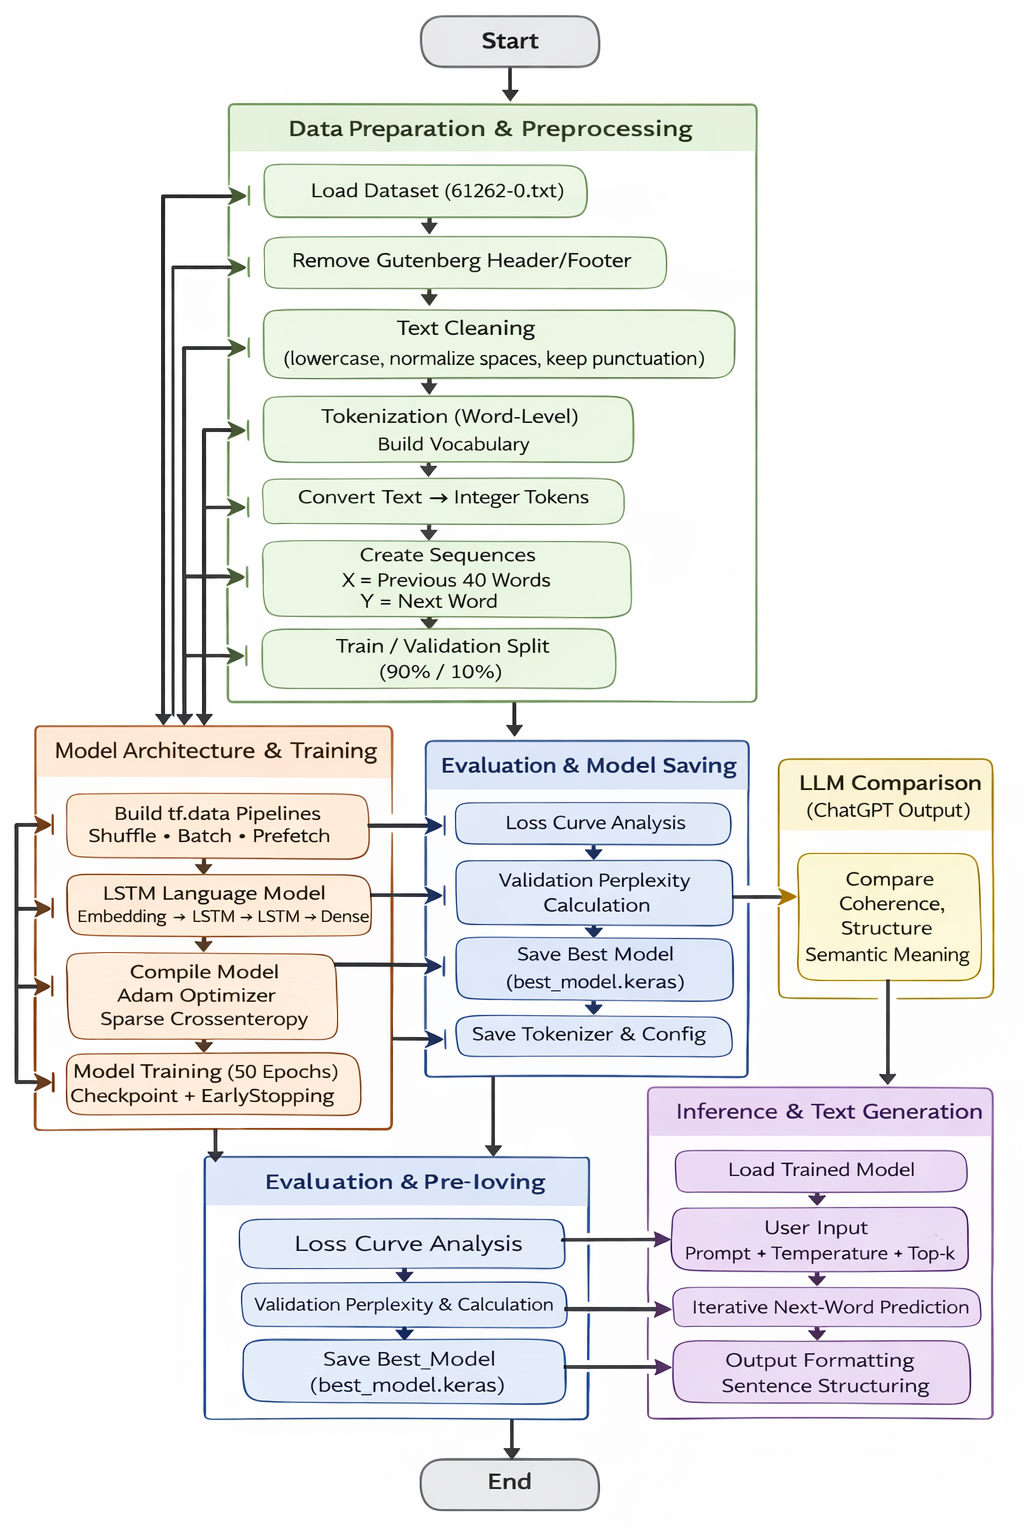

# Text Generation Workflow Using an LSTM-Based Language Model

# **Report**

### **Language Model for Text Generation using Recurrent Neural Networks**

In this project, a word-level language model was developed using the text from *Poirot Investigates* by Agatha Christie. The aim of the model is to learn patterns in the text and predict the next word in a sequence, allowing it to generate new text in a similar style. The dataset was first cleaned by removing Project Gutenberg metadata, converting text to lowercase, normalising spaces, and removing non-ASCII characters while keeping punctuation so that sentence structure could be preserved.

The cleaned text was tokenized into words and converted into numerical sequences using a tokenizer. Sequences of 41 words were created, where the first 40 words were used as input and the next word was used as the target output. This allows the model to learn contextual relationships between words and predict the most likely continuation of a sentence.

An LSTM-based recurrent neural network was implemented using the Keras Sequential API. The model consists of an embedding layer followed by two LSTM layers and dense layers for prediction. Dropout and layer normalisation were used to improve generalisation and reduce overfitting. The model was trained using the Adam optimizer with sparse categorical cross-entropy loss for 50 epochs, while early stopping and checkpointing were used to retain the best-performing model.

Training and validation loss curves showed stable convergence during training. The generated text demonstrates that the model learns local grammatical structure and stylistic patterns from the dataset, although long-range coherence remains limited due to the small dataset size and fixed sequence length.

---

### **Different Approaches to the Problem**

Several alternative approaches could further improve performance. Bidirectional LSTM models can capture context from both past and future words, while transformer-based architectures are better at modelling long-range dependencies in text. Simpler architectures such as GRU can reduce computation time, and pretrained embeddings can improve semantic understanding when training data is limited.

---

### **Techniques to Improve Text Prediction Performance**

The following techniques could improve performance, ordered from highest expected impact:

1. Using transformer-based architectures to better capture long-range dependencies.
2. Initialising embeddings with pretrained vectors such as GloVe or Word2Vec.
3. Applying subword tokenization to better handle rare words.
4. Using bidirectional sequence modelling.
5. Sharing weights between embedding and output layers.
6. Training with progressively longer or more complex sequences.
7. Applying stronger regularisation techniques during training.

---

### **Comparison with Large Language Models**

The generated output was compared with text produced by a large language model using the same prompt. While the LSTM model captures vocabulary and short-range sentence structure from the training data, large language models generate more fluent and coherent text. This is mainly because transformer-based models are trained on much larger datasets and are able to model long-range dependencies more effectively. The comparison highlights both the strengths and limitations of recurrent neural network-based language models for text generation.


## **References**

- Lucid chart was used for designing and visualising the workflow flowchart.  
- Generative AI tools were used to improve clarity of language and presentation.  
- General background knowledge on language models and text generation techniques was referred to from publicly available online resources.
